# 🌳 Trees, Gini and more!

## 🗂️ Project structure

1. Following the task description, you'll find a set of formal requirements that your solution must meet.
2. The primary measure of your success is the **test** accuracy of your machine learning model.
3. After completing each task, you must answer a series of questions, marked with ❓, to demonstrate your understanding of the techniques used.
4. You may create as many cells as needed, but the final results should be kept in a short and simple cell.

## 🧪 A note on test data

In a departure from real-world scenarios, you will have access to the target variables of the test sets for each task. This has been arranged to facilitate the evaluation of your models. However, remember that in actual machine learning projects, test targets are not available, as predicting these is the ultimate goal of your supervised models.

## 📝 Submission guidelines

- For each problem, provide your code solution and model results inside this notebook.
- Answer the follow-up questions in markdown format within this notebook. A few sentences are enough; there is no length requirement.
- Ensure your explanations are clear, concise, and demonstrate a deep understanding of the techniques employed.
- Some questions and tasks are a bit vague. You are expected to apply techniques we learned in the lectures.
- Submit this notebook to Canvas. Deliver the notebook with its outputs saved; ideally, *restart* the kernel and then *run all*.

Good luck!

---

# 🌴 Problem 1: Fit a decision tree classifier!

### ❗️ The problem
In this first problem, you must load the data and train a decision tree classifier on the provided dataset!

### 📋 Formal requirements
1. **Implementation**:
   - Load `problem1.csv`
   - Analyse the dataset (e.g. the class distribution)
   - Preprocess the training data
   - Train a decision tree classifier
   - Implement the metrics presented in the lectures
2. **Performance**: Achieve at least **0.90** classification accuracy on the test set
3. **Discussion**:
   - What preprocessing do we need to apply before training, and why?
   - Do we need to scale the features?
   - What do you observe in the decision boundary plot before and after preprocessing?
   - What happens when you increase or decrease the depth of the tree?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sklearn

In [2]:
%load_ext autoreload

In [3]:
# ====================================
# YOUR CODE GOES HERE: load the data from the problem1.csv file

train_df = pd.read_csv("problem1.csv")
print(train_df)
# ====================================


            x0        x1    y  split
0     1.469311 -0.816098  1.0  train
1     1.558715 -0.966211  1.0  train
2     0.063461  0.206364  1.0  train
3     0.025497  0.326340  1.0  train
4     0.130497  0.456340  1.0  train
...        ...       ...  ...    ...
1301  2.373187  2.532429  1.0   test
1302  2.694128  3.303043  1.0   test
1303  2.968585  3.831259  1.0   test
1304 -1.492249 -1.985090  0.0   test
1305  1.948706  2.484143  1.0   test

[1306 rows x 4 columns]


y
0.0    930
1.0     76
Name: count, dtype: int64
y
0.0    0.92
1.0    0.08
Name: proportion, dtype: float64
y
0.0    150
1.0    150
Name: count, dtype: int64
y
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


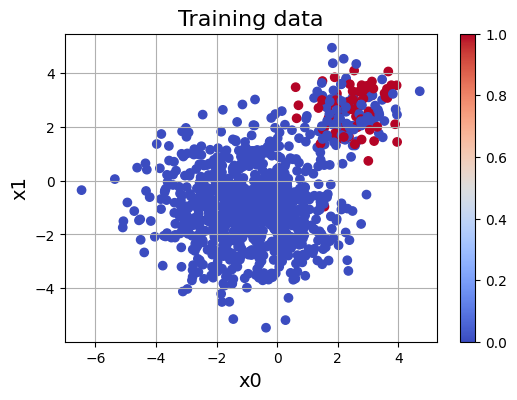

In [4]:
# ====================================
# YOUR CODE GOES HERE: let's analyse the dataset
train = train_df[train_df["split"] == "train"] 
test = train_df[train_df["split"] == "test"]
# ====================================
# Analyse av treningsdata
antall_per_klasse = train["y"].value_counts()
andel_per_klasse = train["y"].value_counts(normalize=True)
print(antall_per_klasse)
print(andel_per_klasse.round(2))

# ====================================
# Analyse av testdata
antall_per_klasse_test = test["y"].value_counts()
andel_per_klasse_test = test["y"].value_counts(normalize=True)
print(antall_per_klasse_test)
print(andel_per_klasse_test.round(2))

# ====================================
# Plotting av treningsdata
plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('Training data', fontsize=16)
plt.colorbar()
plt.show()

# Vi ser utifra plottet etter analysen av treningsdataene at y = 0 er overrepresentert i stor grad, 92% av tilfellene.
# Modellen vil derfor kunne gjøre det godt dersom den gjetter y = 0 på alle, da vil den oppnå score på 0,92. 
# En resampling av dataene vil derfor være nødvendig.

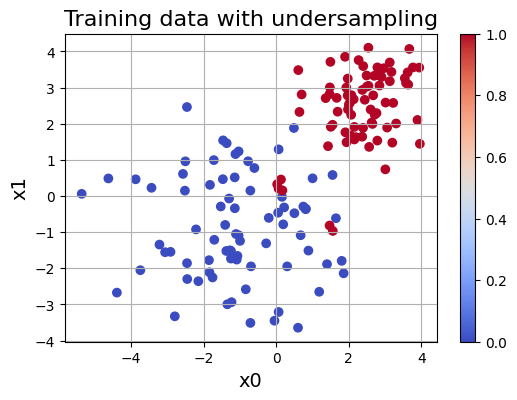

In [5]:
# UNDERSAMPLING
# Ønsker her å resample dataene, slik at de blir jevenere fordelt. Dette kan gjøres enten med undersampling eller oversampling
# Vi hadde 930 verdier for y=0 og kun 76 verdier for y = 1. Det betyr at det kan bli veldig underfit hvis vi kun trekker 
# 76 tilfeldige fra de 930:
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv("problem1.csv") #KOMMENTAR TIL MEG SELV HER: Skjønner ikke helt når de "husker" det som er importert fra andre celler og ikke
train = train_df[train_df["split"] == "train"] 

neg = train[train["y"] == 0]
pos = train[train["y"] == 1]

neg_under = neg.sample(n=len(pos), random_state=42)
train_undersampled = pd.concat([neg_under, pos])

X_train_undersampled = train_undersampled[['x0', 'x1']]
y_train_undersampled = train_undersampled['y']


# PLOTTING AV DATAENE
# ====================================
plt.figure(figsize=(6, 4))
plt.scatter(train_undersampled['x0'], train_undersampled['x1'], c=train_undersampled['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('Training data with undersampling', fontsize=16)
plt.colorbar()
plt.show()


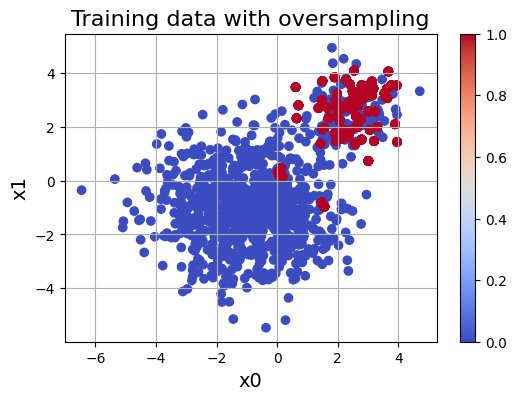

In [6]:
# OVERSAMPLING
# Nå gjør vi det samme med oversampling. Da må vi kopiere instanser av de 76 verdiene slik at de blir 930. Dette vil jo
# være kopier av de samme punktene så plottet vil jo se likt ut bare med mange duplikater.
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv("problem1.csv") #KOMMENTAR TIL MEG SELV HER: Skjønner ikke helt når de "husker" det som er importert fra andre celler og ikke
train = train_df[train_df["split"] == "train"] 

neg = train[train["y"] == 0]
pos = train[train["y"] == 1]

pos_over = pos.sample(n=len(neg), replace=True, random_state=42)
train_oversampled = pd.concat([neg, pos_over])

X_train_oversampled = train_oversampled[['x0', 'x1']]
y_train_oversampled = train_oversampled['y']


# PLOTTING AV DATAENE
# ====================================
plt.figure(figsize=(6, 4))
plt.scatter(train_oversampled['x0'], train_oversampled['x1'], c=train_oversampled['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('Training data with oversampling', fontsize=16)
plt.colorbar()
plt.show()


In [7]:
# MED UNDERSAMPLING

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_train = train[['x0', 'x1']]
y_train = train['y']
X_test = test[['x0', 'x1']]
y_test = test['y']



# ====================================
# YOUR CODE GOES HERE
clf = DecisionTreeClassifier(max_depth = 10)
clf.fit(X_train_undersampled, y_train_undersampled) # Fit-funksjonen, lære seg treningsdataene
y_pred = clf.predict(X_test) # Predikere y_verdier basert på testdata for X
accuracy = accuracy_score(y_test, y_pred) #Sjekke prediksjon oppimot testdataene tilgjengelig
depth = clf.get_depth() # Hente ut dybden
# ====================================

# ====================================
print(f'Accuracy: {accuracy:.2f}, Dybde: {depth}')

# Med max_depth = None er accuracy 0.90
# Med max_depth = 10 er accuracy 0.90
# Med max_depth = 8 er accuracy 0.90
# Med max_depth = 5 er accuracy 0.90
# Med max_depth = 3 er accuracy 0.91

# Refleksjon: Veldig lik accuracy her, sannsynligvis har de ulike max_depthene samme dybde
# Dette er vel fordi det er så lite data, at man ikke kan bygge et dypere beslutningstre? 
# Det er jo ganske kraftige undersamplede data. Det er jo også tilfeldig hvilke data som blir valgt, og kanskje
# hadde det blitt annerledes hvis man trakk data på nytt.


Accuracy: 0.90, Dybde: 5


In [8]:
# MED OVERSAMPLING

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_train = train[['x0', 'x1']]
y_train = train['y']
X_test = test[['x0', 'x1']]
y_test = test['y']



# ====================================
# YOUR CODE GOES HERE
clf = DecisionTreeClassifier(max_depth=2)
clf.fit(X_train_oversampled, y_train_oversampled) # Fit-funksjonen, lære seg treningsdataene
y_pred = clf.predict(X_test) # Predikere y_verdier basert på testdata for X
accuracy = accuracy_score(y_test, y_pred) #Sjekke prediksjon oppimot testdataene tilgjengelig
depth = clf.get_depth() # Hente ut dybden
# ====================================

# ====================================
print(f'Accuracy: {accuracy:.2f}, Dybde: {depth}')

# Med max_depth = None er accuracy 0.69
# Med max_depth = 10 er accuracy 0.83
# Med max_depth = 8 er accuracy 0.88
# Med max_depth = 5 er accuracy 0.86
# Med max_depth = 3 er accuracy 0.89
# Med max_depth = 2 er accuracy 0.93


Accuracy: 0.93, Dybde: 2


In [9]:
# MED class_weights = balanced (ENDELIG MODELL)

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_train = train[['x0', 'x1']]
y_train = train['y']
X_test = test[['x0', 'x1']]
y_test = test['y']



# ====================================
# YOUR CODE GOES HERE
clf = DecisionTreeClassifier(max_depth=3, class_weight="balanced")
clf.fit(X_train, y_train) # Fit-funksjonen, lære seg treningsdataene
y_pred = clf.predict(X_test) # Predikere y_verdier basert på testdata for X
accuracy = accuracy_score(y_test, y_pred) #Sjekke prediksjon oppimot testdataene tilgjengelig
depth = clf.get_depth() # Hente ut dybden
# ====================================

# ====================================
print(f'Accuracy: {accuracy:.2f}, Dybde: {depth}')

# Med max_depth = None og ubalanserte data ble accuracy = 0.68
# Med max_depth = None og balanserte data ble accuracy = 0.70 (varierer for hver gang men mellom 0.69 og 0.73 uten random state = 42)
# Med max_depth = 10, accuracy = 0.82
# Med max_depth = 5, accuracy = 0.88
# Med max_depth = 3, accuracy = 0.91
# Med max_depth = 2, accuracy = 0.90


Accuracy: 0.91, Dybde: 3


In [10]:
# ====================================
# YOUR CODE GOES HERE: report FPR and TPR alongside other metrics you find relevant (hint: see the lecture notes).
# ====================================

# Utregninger av henholdsvis true og false, positive og negative

TP = np.sum((y_pred == 1) & (y_test == 1))
FP = np.sum((y_pred == 1) & (y_test == 0))
TN = np.sum((y_pred == 0) & (y_test == 0))
FN = np.sum((y_pred == 0) & (y_test == 1))

# Utregninger fra tabell 4 i kompendiet
tpr = TP / (TP + FN) # Recalll
tnr = TN / (TN + FP) # Spesifisitet
fpr = FP / (FP + TN) # Sannsynlighet for falsk alarm
ppv = TP / (TP + FP) # Precision, "av alle modellen sa var positive, hvor mange var det faktisk?"

# ====================================
print(f"True positive rate: {tpr:.3f}")
print(f"True negative rate: {tnr:.3f}")
print(f"False positive rate: {fpr:.3f}")
print(f"Positive Predictive Value: {ppv:.3f}")

True positive rate: 0.987
True negative rate: 0.833
False positive rate: 0.167
Positive Predictive Value: 0.855


### ❓ What preprocessing do we need to apply before training, and why?


### ❓ Do we need to scale the features?

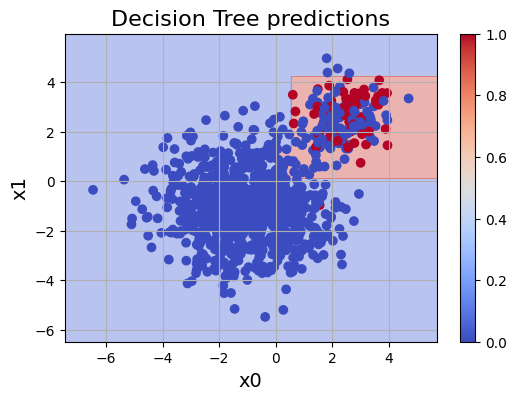

In [11]:
# visualize the decision boundary
x0_min, x0_max = train['x0'].min() - 1, train['x0'].max() + 1
x1_min, x1_max = train['x1'].min() - 1, train['x1'].max() + 1
xx0, xx1 = np.meshgrid(np.arange(x0_min, x0_max, 0.01),
                       np.arange(x1_min, x1_max, 0.01))

grid = pd.DataFrame({'x0': xx0.ravel(), 'x1': xx1.ravel()})
Z = clf.predict(grid)
Z = Z.reshape(xx0.shape)

plt.figure(figsize=(6, 4))
plt.contourf(xx0, xx1, Z, alpha=0.4, cmap='coolwarm')
plt.scatter(X_train['x0'], X_train['x1'], c=y_train, cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('Decision Tree predictions', fontsize=16)
plt.colorbar()
plt.show()

In [12]:
# WHAT PREPROCESSING DO WE NEED TO APPLY BEFORE TRAINING AND WHY?
# Her må vi resample dataene våre, fordi treningsdataene er ubalansert. Dette er fordi ved analysen av dataene våre var 92% av dem y = 0, og dette gjør at modellen
# kan ende opp med å bare gjette y = 0 på alt, og score dårlig på testdataene fordi de er 50/50 balansert. (Vanligvis har man jo ikke testdata tilgjengelig)
# Jeg prøvde derfor å preprosessere både ved undersampling og oversampling. Det enkleste, som jeg endte med å gjøre var å bruke 
# class_weights = "balanced"

# DO WE NEED TO SCALE THE FEATURES?
# Nei, her trenger vi ikke skalering. For det første ligger featurene i et lite intervall, og for det andre multipliseres
# ikke featurene her med vekter, slik som i regresjon. Det eneste nodene i beslutningstreet gjør er å klassifisere basert
# på en terskel, hvor utfallet ikke vil endres ved skalering.

# WHAT DO YOU OBSERVE IN THE DECISION BOUNDARY PLOT BEFORE AND AFTER PREPROCESSING
# Med ubalanserte data får vi mye dårligere prediksjoner, det synes også av plottet. Det røde rektangelet bommer på de røde punktene
# (eller motsatt blir vel riktig). Med balanserte data (etter preprosessering) treffer omtrent alle røde prikker i rød boks. (Altså høy true positive)
# Vi ser at etter preprosessering havner noen blå prikker i rød boks, dette er false positives, men andelen er
# FPR = 0.167, fra den andre cella der.

# WHAT HAPPENS WHEN YOU INCREASE OR DECREASE THE DEPTH OF THE TREE
# Generelt gir dypere trær dårligere accuracy, da dette er et resultat av overfit, hvor modellen lærer seg treningsdataene
# "for godt". Når vi minker dybden øker også accuracien for alle modellene jeg har testet ut, men når dataene er ubalanserte
# altså før preprocessing scorer den høyere på dypere trær. Dette er på grunn av overfit, den pugger treningsdataene

### ❓ What do you observe in the decision boundary plot before and after preprocessing?


### ❓ What happens when you increase or decrease the depth of the tree?


# 🌴🌴 Problem 2: Predict Viking voyage survivors 🗡️
### ❗️ The problem
You are given a dataset with information about the passengers on Viking voyages.
Your task is to develop a decision tree classifier that predicts which Vikings **survived** a **voyage**.

### 📋 Formal requirements
1. **Implementation**:
   - Do a simple data analysis
   - Preprocess the data 
   - Train a decision tree classifier
   - Report the cross-validation score and the test accuracy
   - Try different split criteria for the decision tree
   - Plot the decision tree
   - Use a boosting technique to improve the accuracy!
   - Use Naïve Bayes to predict whether a single new voyager survives
2. **Performance**: Achieve at least **0.80** classification accuracy on the test set
3. **Discussion**:
   - Analyse the dataset. Are there any features that already predict survival better than a random guess?
   - What is the purpose of cross-validation?
   - Which split criterion do you prefer, and why?
   - What is Gini impurity? Use an example from the decision tree graph you created
   - Which terms of Bayes theorem can you estimate from this dataset, and which ones are difficult?
   - Use Naïve Bayes: does the new voyager have a higher or lower chance of surviving?

In [13]:
df = pd.read_csv('problem2.csv')

Let's start by understanding the dataset.

In [14]:
# Let's analyse the dataset
# Make some comments about what you print and what useful information it gives
# ====================================
# YOUR CODE GOES HERE: Let's analyse the dataset!
# ====================================
# I motsetning til for Problem 1, har vi ikke her train og test-data gitt på forhånd. Vi må derfor dele opp selv i train og testdata.

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["survived"])

# Printing og oppdeling av kjønn

antall_per_kjønn = train_df["sex"].value_counts()
andel_per_kjønn = train_df["sex"].value_counts(normalize=True)

print(antall_per_kjønn)
print(andel_per_kjønn)

overlevde = train_df[train_df["survived"] == 1] # Hvor survived = 1

antall_overlevd_per_kjønn = overlevde["sex"].value_counts()
andel_overlevd_per_kjønn = antall_overlevd_per_kjønn / antall_per_kjønn

print(andel_overlevd_per_kjønn.round(2))



#Har printet det litt klønete, men ser at omtrent 35% av menn og 71% av kvinner overlever. 
# ====================================

# Antall tokt
antall_per_tokt = train_df["prior_voyages"].value_counts()
andel_per_tokt = train_df["prior_voyages"].value_counts(normalize=True)

print(antall_per_tokt)
# print(andel_per_tokt.round(2))

antall_overlevd_per_tokt = overlevde["prior_voyages"].value_counts()
andel_overlevd_per_tokt = antall_overlevd_per_tokt / antall_per_tokt

print(andel_overlevd_per_tokt) # Ser på hvor mange som overlever utifra hvor mange tidligere tokt

# Hvilket skip
antall_per_skip = train_df["ship"].value_counts()
andel_per_skip = train_df["ship"].value_counts(normalize=True)

antall_overlevd_per_skip = overlevde["ship"].value_counts()
andel_overlevde_per_skip = antall_overlevd_per_skip / antall_per_skip

print(antall_per_skip)
print(andel_per_skip)
print(antall_overlevd_per_skip)
print(andel_overlevde_per_skip)






sex
Male      292
Female    108
Name: count, dtype: int64
sex
Male      0.73
Female    0.27
Name: proportion, dtype: float64
sex
Male      0.35
Female    0.71
Name: count, dtype: float64
prior_voyages
0    107
1     89
2     85
3     48
4     27
5     24
6      9
7      6
8      3
9      2
Name: count, dtype: int64
prior_voyages
0    0.242991
1    0.359551
2    0.411765
3    0.645833
4    0.629630
5    0.833333
6    0.777778
7    0.833333
8    1.000000
9    1.000000
Name: count, dtype: float64
ship
Ormen Lange    90
Bison          87
Drakvinge      86
Hrafnkell      82
Sjøulven       55
Name: count, dtype: int64
ship
Ormen Lange    0.2250
Bison          0.2175
Drakvinge      0.2150
Hrafnkell      0.2050
Sjøulven       0.1375
Name: proportion, dtype: float64
ship
Ormen Lange    54
Bison          39
Hrafnkell      38
Drakvinge      38
Sjøulven        9
Name: count, dtype: int64
ship
Bison          0.448276
Drakvinge      0.441860
Hrafnkell      0.463415
Ormen Lange    0.600000
Sjøulven  

### ❓ Are there any features that already predict survival better than a random guess?


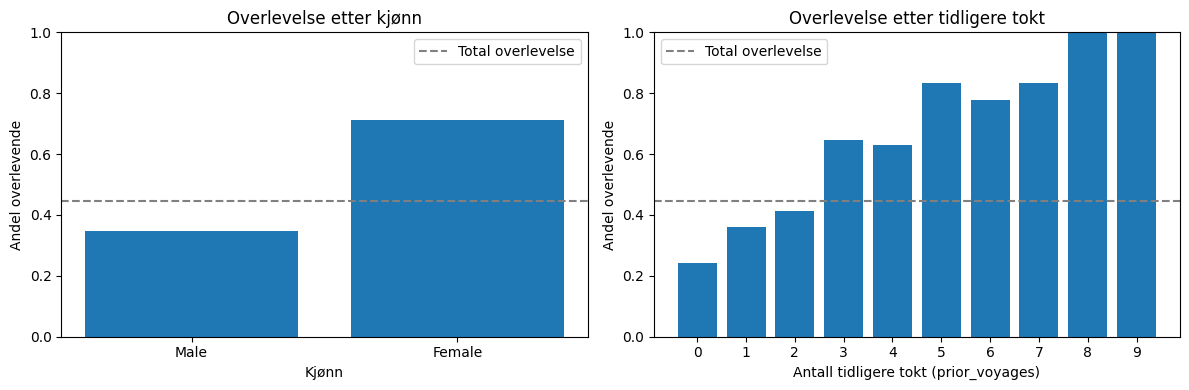

In [15]:
# We see that both sex and prior_voyages effect the survival rate. Women are more likely to survive, and people who have been to 
# several voyages, are also more likely to survive.
# Vi kan studere dataene nærmere med plott:

# Plotting av overlevelse mot kjønn og tidligere tokt
total_overlevelse = train_df["survived"].mean()  # det en tilfeldig gjetning må slå

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Kjønn mot overlevelse
axes[0].bar(andel_overlevd_per_kjønn.index, andel_overlevd_per_kjønn.values)
axes[0].axhline(total_overlevelse, color="gray", linestyle="--", label="Total overlevelse")
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("Kjønn")
axes[0].set_ylabel("Andel overlevende")
axes[0].set_title("Overlevelse etter kjønn")
axes[0].legend()

# Tidligere tokt mot overlevelse (sortert 0, 1, 2, ...)
andel_tokt_sortert = andel_overlevd_per_tokt.sort_index()
axes[1].bar(andel_tokt_sortert.index, andel_tokt_sortert.values)
axes[1].axhline(total_overlevelse, color="gray", linestyle="--", label="Total overlevelse")
axes[1].set_ylim(0, 1)
axes[1].set_xticks(andel_tokt_sortert.index)
axes[1].set_xlabel("Antall tidligere tokt (prior_voyages)")
axes[1].set_ylabel("Andel overlevende")
axes[1].set_title("Overlevelse etter tidligere tokt")
axes[1].legend()

plt.tight_layout()
plt.show()

# Her brukte jeg Claude til å generere kode for plotting. Her ser vi at 3 eller flere tidligere tokt gjør at man har høyere sannsynlighet
# for å overleve en tilfeldig gjetning. Dersom man er mann har man dårligere sjanse for å overleve en tilfeldig gjetning, men dersom man er 
# kvinne, har man høyere overlevelsessannsynlighet.Vi ser at targetverdiene er balanserte.


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score
target = 'survived'
# ====================================
# YOUR CODE GOES HERE: Train the model:)
# Hmmm nå delte jeg opp i treningsdata, og analyserte kun de i den forrige oppgaven. Men oppdelingen er tilfeldig så jaja. 
# Men da gjør jeg vel det samme her
# Jeg tolker oppgaven her som at vi skal bruke kryssvalidering. Vi må som det står i oppgaven preprosessere data, ved å bestemme hvordan
# vi skal bruke dataene i modellen vår. Må først gjøre noen sjekker på alle kolonnene.
# ====================================

# Alle features som inneholder tall kan vi la være som de er. Men role, ship og alt som har tekst må få tall. 
# Roles og armor har tydeligere prioritet fra før, mens resten kan vi bruke get dummies, som skiller op 0 eller 1
df_encoded = df.copy() # Lager en kopi av df

# Encoding fra rolle til tall, vi velger fra 0-3 hvor Jarl har størst verdi:

roles = {"Thrall" : 0, "Karl": 1, "Hirdman" : 2, "Jarl": 3}
df_encoded["role"] = df_encoded["role"].map(roles)

# Encoding for armor i prioritert rekkefølge

armors = {"None": 0, "Leather": 1, "Chainmail": 2, "Lamellar": 3} 
df_encoded["armor"] = df_encoded["armor"].map(armors)

# Encoding for kjønn
sex_dummies = {"Female": 0, "Male": 1} #Mannsjåvinistisk hehe
df_encoded["sex"] = df_encoded["sex"].map(sex_dummies)

# Resten kan få dummy-verdier

df_encoded = pd.get_dummies(df_encoded, columns=["ship", "destination", "clan_origin"],  dtype=int)

# Fylle ut tomme alderkolonner
# df_encoded["age"] = df_encoded["age"].fillna(train_df["age"].median())
# KOMMENTAR: har foreløpig valgt å ignorere at det er ukjente verdier noen plasser
# Kanskje dette senere kan være et forbedringspotensiale for modellen??

# Vi deler opp i trenings- og testdata

train_df_encoded, test_df_encoded = train_test_split(df_encoded, test_size=0.2, random_state=42)#stratify=df_encoded["survived"]) Gjør det dårligere med denne faktisk


train_X, test_X = train_df_encoded.drop(columns=["passenger_id", "name", "survived"]), test_df_encoded.drop(columns=["passenger_id", "name", "survived"])
train_y, test_y = train_df_encoded["survived"], test_df_encoded["survived"]

# Trene modellen med beslutningstre
vikings = DecisionTreeClassifier(max_depth=3)
cv_scores = cross_val_score(vikings, train_X, train_y, cv=5)
vikings.fit(train_X, train_y) # Fit-funksjonen, lære seg treningsdataene
survived_pred = vikings.predict(test_X) # Predikere y_verdier basert på testdata for X
vikings_accuracy = accuracy_score(test_y, survived_pred) #Sjekke prediksjon oppimot testdataene tilgjengelig

dybde = vikings.get_depth()  # Dybden til beslutnignstreet
# ====================================
print(f"CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(dybde)
print(f"Test accuracy: {vikings_accuracy:.4f}")

CV Accuracy: 0.752 ± 0.044
3
Test accuracy: 0.7600


### ❓ What is the purpose of cross validation?


In [ ]:
# Compare the different split criteria
# ====================================
# YOUR CODE GOES HERE: try the different split criteria (gini, entropy, log_loss)
# and report the cross-validation and test accuracy for each
# ====================================

# Gini er standard, så her kan vi legge inn akkurat det samme, men også for entropy og log_loss

# ENTROPY

vikings_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=5)
cv_scores = cross_val_score(vikings_entropy, train_X, train_y, cv=5)
vikings_entropy.fit(train_X, train_y) # Fit-funksjonen, lære seg treningsdataene
survived_pred = vikings_entropy.predict(test_X) # Predikere y_verdier basert på testdata for X
vikings_entropy_accuracy = accuracy_score(test_y, survived_pred) #Sjekke prediksjon oppimot testdataene tilgjengelig

dybde = vikings_entropy.get_depth()  # Dybden til beslutnignstreet

print(f"CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(dybde)
print(f"Test accuracy: {vikings_entropy_accuracy:.4f}")

#Kommentar: noe dårligere CV accuracy, men lik test accuracy

# LOG_LOSS

vikings_log_loss = DecisionTreeClassifier(criterion='log_loss', max_depth=5)
cv_scores = cross_val_score(vikings_log_loss, train_X, train_y, cv=5)
vikings_log_loss.fit(train_X, train_y) # Fit-funksjonen, lære seg treningsdataene
survived_pred = vikings_log_loss.predict(test_X) # Predikere y_verdier basert på testdata for X
vikings_log_loss_accuracy = accuracy_score(test_y, survived_pred) #Sjekke prediksjon oppimot testdataene tilgjengelig

dybde = vikings_log_loss.get_depth()  # Dybden til beslutnignstreet

print(f"CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(dybde)
print(f"Test accuracy: {vikings_log_loss_accuracy:.4f}")

# Kommentar: log_loss og entropy ser ut til å gi helt lik. Begge får 0.01 høyere med max_depth 5 istedenfor 3.
# Er entropi og log_loss det samme for beslutningstrær?


CV Accuracy: 0.745 ± 0.029
5
Test accuracy: 0.7700
CV Accuracy: 0.750 ± 0.037
5
Test accuracy: 0.7700


### ❓ Try different DecisionTreeClassifier criteria, report what accuracy you get. Which criterion do you prefer?


[Text(0.5, 0.875, 'role <= 1.5\ngini = 0.489\nsamples = 400\nvalue = [229, 171]'),
 Text(0.25, 0.625, 'sex <= 0.5\ngini = 0.428\nsamples = 296\nvalue = [204, 92]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'ship_Ormen Lange <= 0.5\ngini = 0.475\nsamples = 90\nvalue = [35.0, 55.0]'),
 Text(0.0625, 0.125, 'gini = 0.5\nsamples = 64\nvalue = [31, 33]'),
 Text(0.1875, 0.125, 'gini = 0.26\nsamples = 26\nvalue = [4, 22]'),
 Text(0.375, 0.375, 'armor <= inf\ngini = 0.295\nsamples = 206\nvalue = [169, 37]'),
 Text(0.3125, 0.125, 'gini = 0.467\nsamples = 43\nvalue = [27, 16]'),
 Text(0.4375, 0.125, 'gini = 0.224\nsamples = 163\nvalue = [142, 21]'),
 Text(0.75, 0.625, 'ship_Sjøulven <= 0.5\ngini = 0.365\nsamples = 104\nvalue = [25, 79]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'provisions_kg <= 22.0\ngini = 0.263\nsamples = 90\nvalue = [14, 76]'),
 Text(0.5625, 0.125, 'gini = 0.393\nsamples = 41\nvalue = [11, 30]'),
 Text(0.6875, 0.125, 'gini = 0.115\nsamples = 49\nvalue = [3

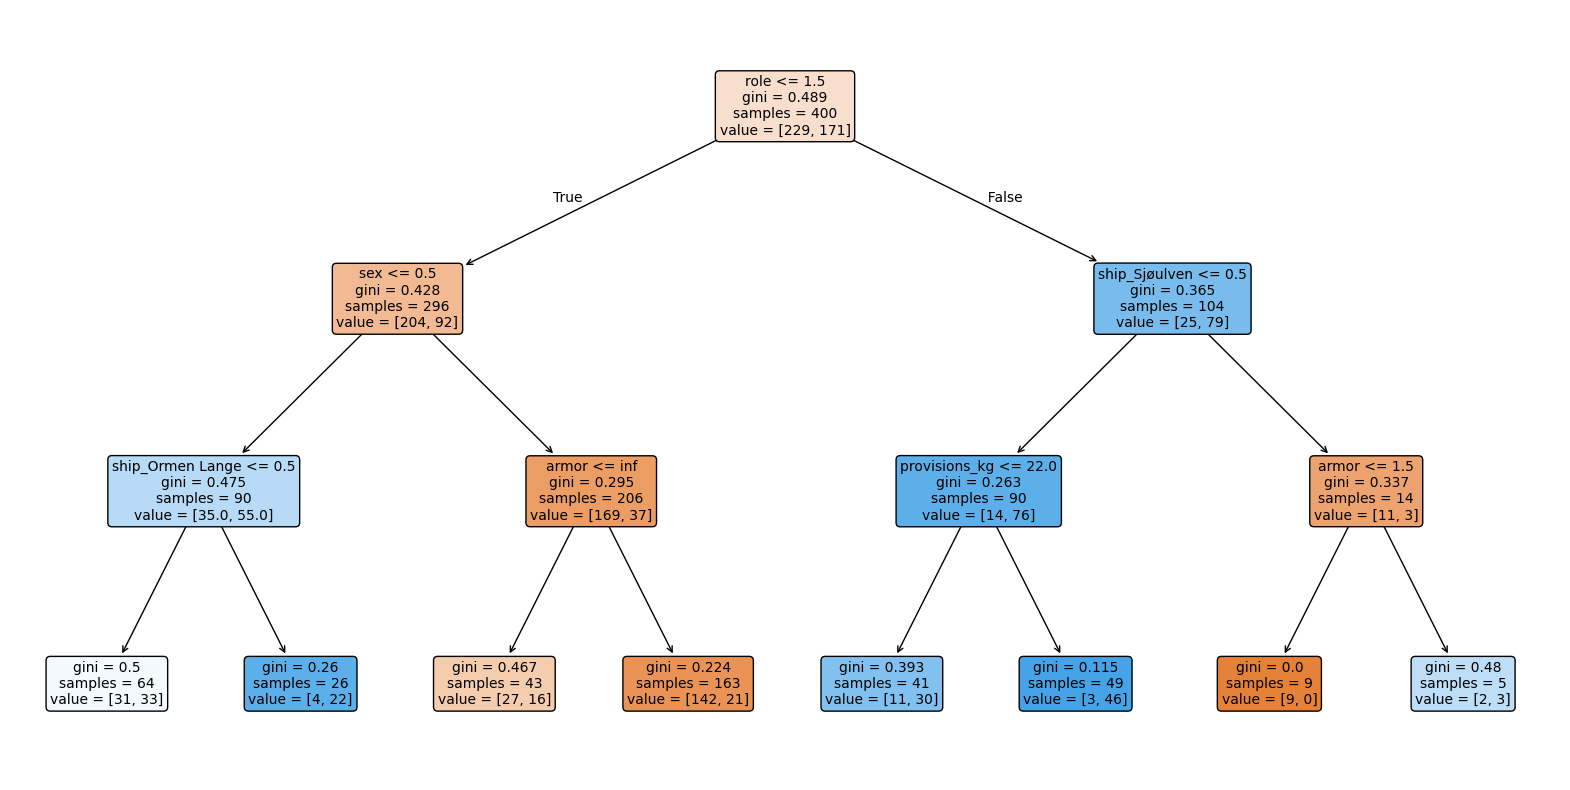

In [51]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# ====================================
# YOUR CODE GOES HERE: Plot the decision tree nodes!
plt.figure(figsize=(20,10))
plot_tree(vikings, feature_names=train_X.columns, filled=True, rounded=True, fontsize=10)
# plot_tree(vikings_entropy)
# plot_tree(vikings_log_loss) 
# ====================================


### ❓ What is Gini? Use an example from the decision tree graph you created.


In [ ]:
# FY DÆVEN DETTE ER SYKT, WHAAAAT

## Improving the results with boosting 🚀

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
# ====================================
# YOUR CODE GOES HERE: Use AdaBoostClassifier to get even better results!
# ====================================

# ====================================
ada_acc = accuracy_score(y_test, y_pred_ada)
print(f"AdaBoost CV Accuracy: {ada_cv_scores.mean():.3f} ± {ada_cv_scores.std():.3f}")
print(f"AdaBoost test accuracy: {ada_acc:.4f}")

NameError: name 'y_pred_ada' is not defined

### ❓ Try estimating the factors of Bayes theorem using this dataset. What terms can you estimate and which ones are difficult and why?
$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

In [ ]:
# ====================================
# YOUR CODE GOES HERE: estimate the terms of Bayes theorem you can
# ====================================


### ❓ Use Naïve Bayes. Does Endre have a higher or lower chance of surviving than dying on a voyage?

A voyager named **Endre** is about to set sail. This is what we know about him:

| Feature | Value |
| --- | --- |
| `sex` | Male |
| `age` | 25 |
| `role` | Hirdman |
| `ship` | Drakvinge |
| `destination` | Normandy |
| `clan_origin` | Nidaros |
| `armor` | Chainmail |
| `provisions_kg` | 49 |
| `family_aboard` | 2 |
| `prior_voyages` | 12 |

Does he have a **higher or lower** chance of surviving the voyage?

In [ ]:
# ====================================
# YOUR CODE GOES HERE: Naïve Bayes
# You can either do this by hand or with code.
# Do not import libraries.
# ====================================
